## 3.3 MPC feasibility

**(a)**

In [1]:
import cvxpy as cvx
def do_mpc(x0, A, B, P, Q, R, N, rx, ru, rf):
    n, m = Q.shape[0], R.shape[0]
    x_cvx = cvx.Variable((N + 1, n))
    u_cvx = cvx.Variable((N, m))

    cost = cvx.quad_form(x_cvx[N], P)
    for k in range(N):
        cost += cvx.quad_form(x_cvx[k], Q) + cvx.quad_form(u_cvx[k], R)

    constraints = [x_cvx[0] == x0]
    for k in range(N):
        constraints += [
            x_cvx[k + 1] == A @ x_cvx[k] + B @ u_cvx[k],
            cvx.norm_inf(x_cvx[k]) <= rx,
            cvx.norm_inf(u_cvx[k]) <= ru,
        ]
    constraints += [cvx.norm_inf(x_cvx[N]) <= rf]

    prob = cvx.Problem(cvx.Minimize(cost), constraints)
    prob.solve(cvx.CLARABEL)
    return x_cvx.value, u_cvx.value, prob.status

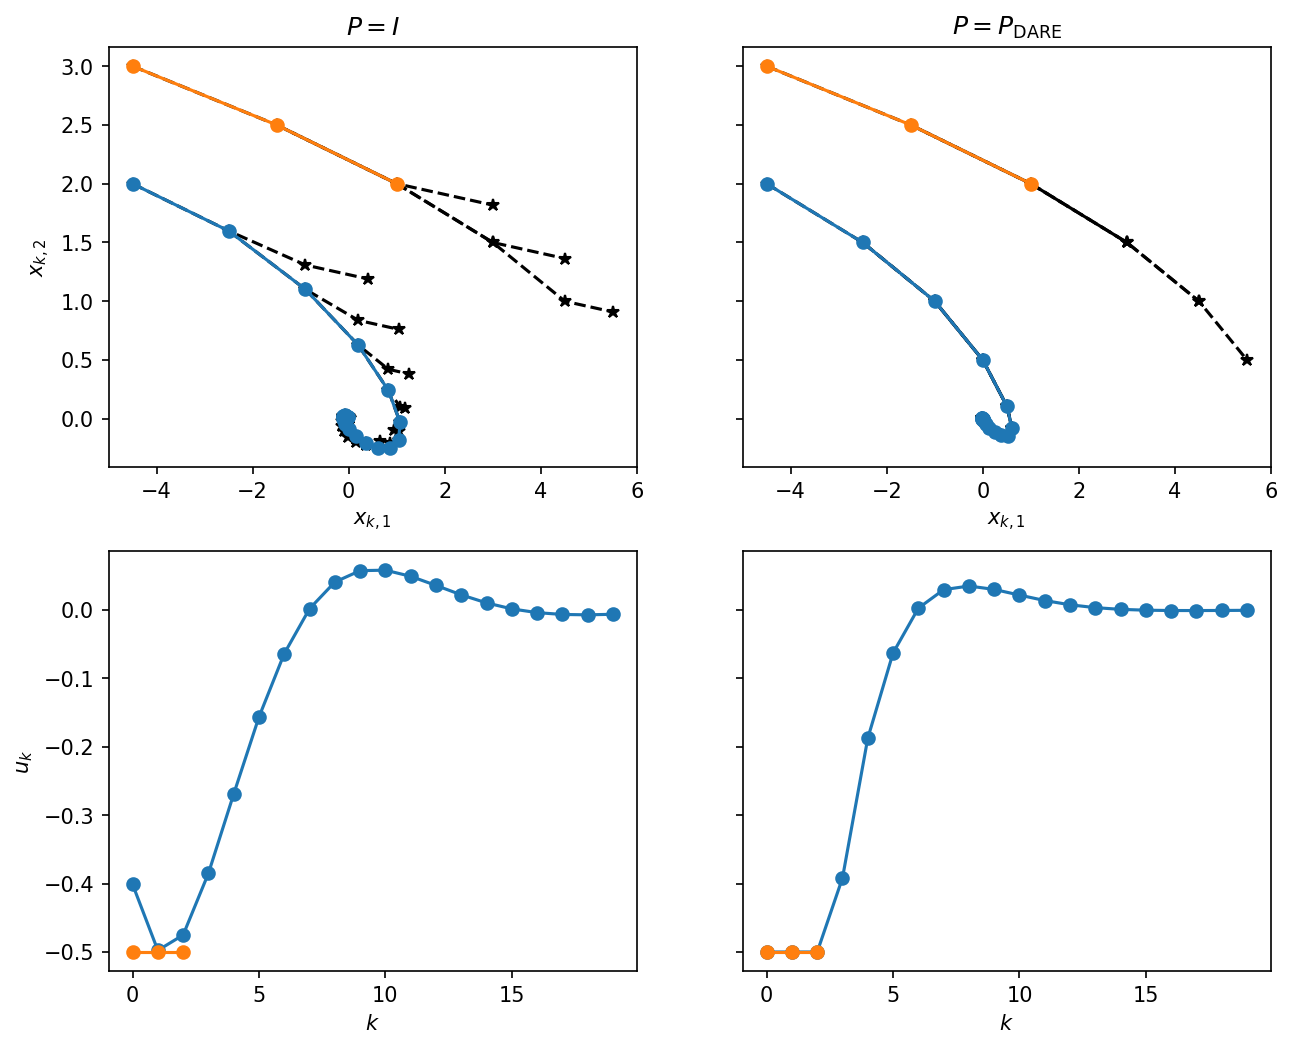

In [2]:
from IPython.display import Image, display
display(Image(filename='mpc_feasibility_sim.png', width=700))

For both values of $P$, the initial condition $x_0 = (-4.5, 2)$ (blue) converges to the origin. With $P = I$, convergence is slower and the predicted open-loop trajectories (dashed stars) diverge from the realized closed-loop trajectory. $P = I$ underestimates the true cost-to-go beyond the horizon, so the planner does not penalize the terminal state enough. With $P = P_\mathrm{DARE}$, the predicted open-loop steps nearly coincide with the closed-loop trajectory (the stars overlap the dots), because $P_\mathrm{DARE}$ is the true infinite-horizon cost-to-go for the unconstrained LQR, so replanning produces essentially the same trajectory.

The initial condition $x_0 = (-4.5, 3)$ (orange) becomes infeasible at $t = 3$ for both values of $P$. The control saturates at $u = -0.5$ for all steps but the initial velocity $x_2 = 3$ is too large. The state drifts to $(3.0, 1.5)$ where MPC cannot find a feasible plan that satisfies $\|x_k\|_\infty \le 5$ over the next $N = 3$ steps. This initial condition is outside the region of attraction for this MPC configuration regardless of the choice of $P$.

**(b)**

In [3]:
import numpy as np 
def compute_roa(A, B, P, Q, R, N, rx, ru, rf, grid_dim=21, max_steps=20, tol=1e-2):
    roa = np.zeros((grid_dim, grid_dim))
    xs = np.linspace(-rx, rx, grid_dim)
    for i, x1 in enumerate(xs):
        for j, x2 in enumerate(xs):
            x = np.array([x1, x2])
            for _ in range(max_steps):
                x_mpc, u_mpc, status = do_mpc(x, A, B, P, Q, R, N, rx, ru, rf)
                if status == "infeasible":
                    break
                x = A @ x + B @ u_mpc[0, :]
                if np.linalg.norm(x) <= tol:
                    roa[i, j] = 1
                    break
    return roa

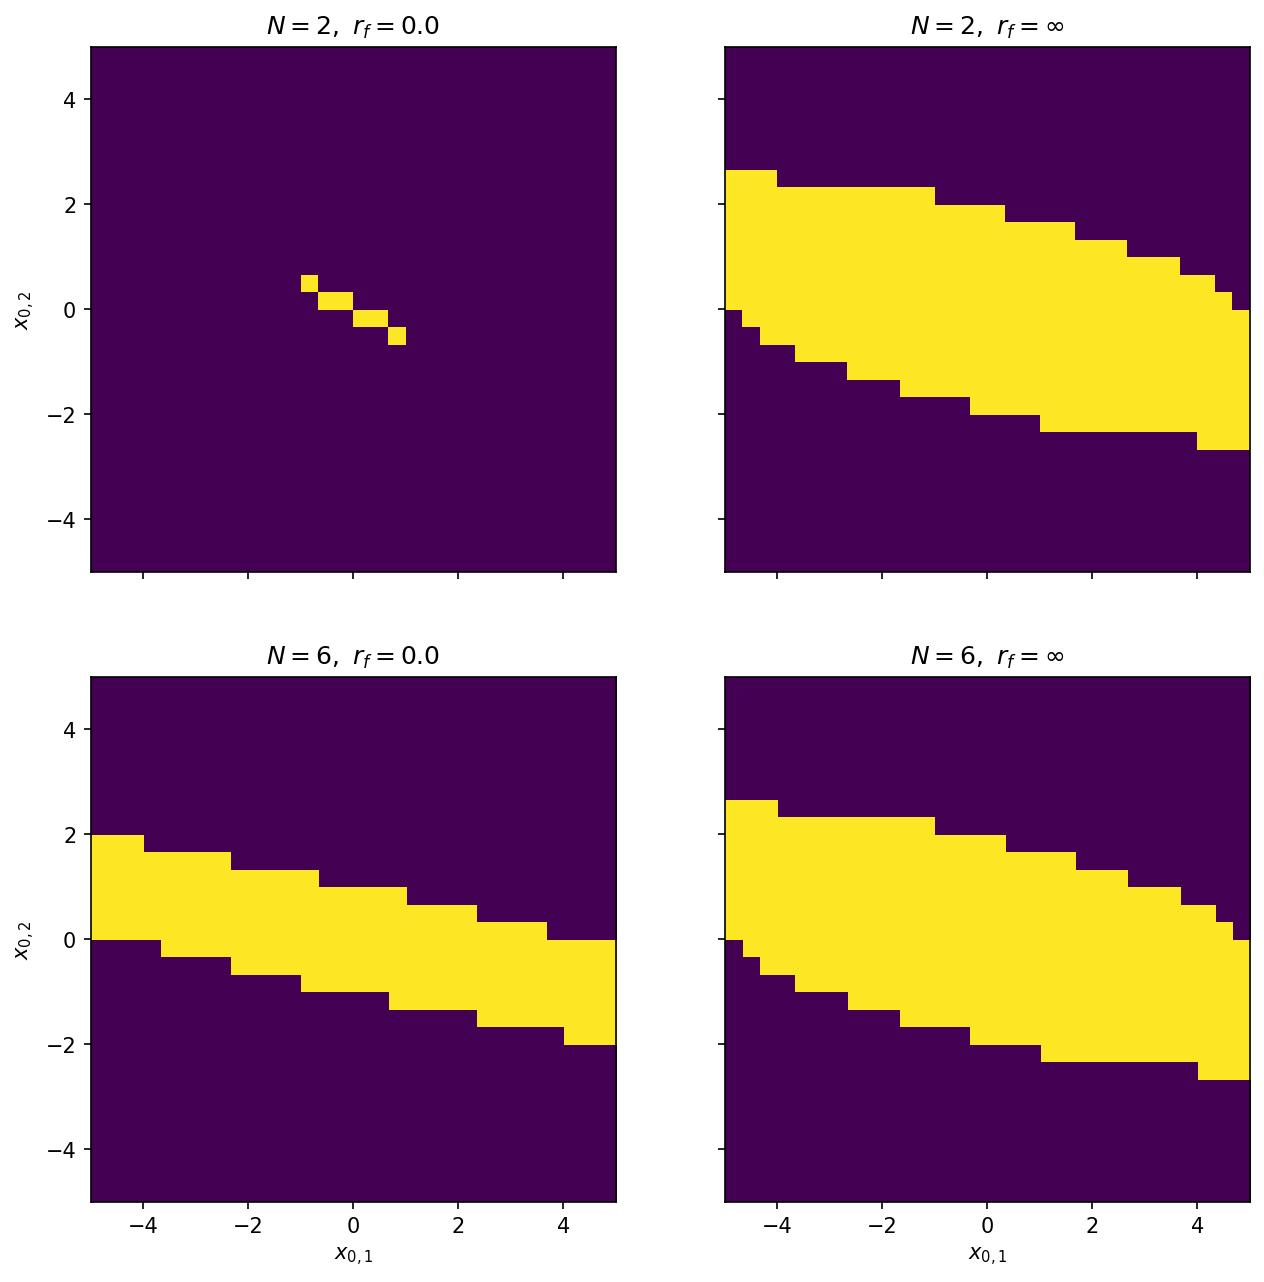

In [4]:
from IPython.display import Image, display
display(Image(filename='mpc_feasibility_roa.png', width=700))

The ROA grows as we increase $N$ and as we relax $r_f$.

With $r_f = 0$, the MPC must drive the state exactly to the origin within $N$ steps. For $N = 2$ this is extremely restrictive: only a tiny set of initial states near the origin can reach $x = 0$ in 2 steps with $\|u\|_\infty \le 0.5$, resulting in an almost empty ROA. Increasing to $N = 6$ gives the controller more steps to steer to the origin, so the ROA grows significantly.

With $r_f = \infty$, there is no terminal constraint. The MPC only needs to keep $\|x_k\|_\infty \le r_x$ and $\|u_k\|_\infty \le r_u$ over the horizon, which is a much weaker requirement. The ROA increases because more states admit a feasible plan: the controller no longer has to reach any specific terminal state within $N$ steps, it just has to stay within the state constraints.

Increasing $N$ also enlarges the ROA in both cases, since a longer horizon gives the controller more freedom to plan a feasible trajectory. However, the effect of $r_f$ is more dramatic: going from $r_f = 0$ to $r_f = \infty$ at $N = 2$ produces a much larger jump in ROA than going from $N = 2$ to $N = 6$ at fixed $r_f$.

The diagonal shape of the ROA reflects the system dynamics: since $x_1$ represents position and $x_2$ velocity, states where $x_1$ and $x_2$ have the same sign (e.g., $x_1 > 0, x_2 > 0$) are harder to control back to the origin because the velocity pushes the position further away, while states where $x_2$ opposes $x_1$ are naturally returning.